# 02 — BRT Diagnostics (Step 3 verification)

Visually confirms that the **uncontrolled backward-reachable tube** in
`reachability/hopf.py` is correct, beyond the passing unit tests.

`value()` is a **tube**, not a single-time set:

$$V(x,t) = \min_{\tau \in [t,T]} \; l\big(\Phi(\tau-t)\,x\big)$$

i.e. a state is unsafe (V < 0) if its trajectory enters the collision sphere at
**any** $\tau$ in the remaining window $[t,T]$ — not only at the final instant
$T$. This is required for our 7 km/s crossing: the objects are inside the 10 m
sphere for only ~milliseconds and essentially never exactly at $T$, so a
single-time check would miss the collision. (Earlier versions of these figures
were drawn for the single-time *set* $l(\Phi(T-t)x)$; the meaning of Figs 1–3
shifts accordingly — each cell's prose flags how.)

These are **diagnostic** figures (to catch bugs), *not* paper figures — the
headline Pc(t) curve comes later in Step 5. This notebook **imports** the
library functions; it never re-derives `value()` inline, so a bug in `hopf.py`
must surface here rather than being masked by parallel notebook code.

Three figures:
1. BRT boundary in the dr–dt plane at several times (geometry + time direction)
2. BRT membership heatmap (sign convention + velocity-dependence)
3. `value(x(t), t)` along trajectories (bridge to trusted separation distance)

**Resolution note (honest limitation):** the min-over-$\tau$ is approximated by
a coarse bracket then Brent-refine of every local minimum. The bracket spacing
is auto-sized to `L_basin / v_rel` but **capped** at 200k samples; over the full
~24 hr window at 7 km/s the cap is hit, so the auto grid is coarser than the
nominal target. The genuinely-colliding trajectories shown here pass *deep*
through the sphere (wide, seconds-long valley), so a modest explicit `n_time`
brackets them reliably — but a *grazing* fast pass over a multi-hour window would
need the per-call cost addressed (vectorized `expm` over the τ-grid). That is a
Step-5 performance item, noted in the session log.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

from spacecraft_brt.dynamics.hcw import (
    hcw_state_transition,
    propagate_hcw,
    separation_distance,
    time_of_closest_approach,
)
from spacecraft_brt.dynamics.scenario import make_crossing_conjunction
from spacecraft_brt.reachability.hopf import value, brt_boundary_points
from spacecraft_brt.reachability.target_set import signed_distance
from spacecraft_brt.utils.constants import R_HBR_DEFAULT, PC_THRESHOLD

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
RNG = np.random.default_rng(0)

# value() is now a TUBE: V(x,t) = min over tau in [t,T] of l(Phi(tau-t) x). For a
# trajectory step we want the running-minimum (will I be in the sphere at ANY
# tau >= t), so a modest coarse bracket suffices: these trajectories pass DEEP
# through the sphere, so the closest-approach valley is wide (seconds), not the
# ms-long sub-sphere dwell. n_time=2000 brackets that valley over the full ~24 hr
# window; refine then nails the exact closest approach. (The auto grid would size
# to the cap of 200k samples over 24 hr -> ~3.8 s/call; here we don't need it.)
_TRAJ_N_TIME = 2000


def value_along_trajectory(states, t_eval, T, n, hard_body_r):
    """Evaluate the TUBE value V(x(t), t) with each state at ITS OWN time t.

    value() shares one set of Phi matrices across a batch at a single fixed t;
    here every timestep has a different t (and hence a different remaining
    window [t, T]), so we loop -- one value() call per step. We pass an explicit
    n_time so each call brackets the deep close-approach valley cheaply rather
    than auto-sizing to the window cap. See module note above.
    """
    return np.array([
        float(value(states[i], t=t_eval[i], T=T, n=n,
                    hard_body_r=hard_body_r, n_time=_TRAJ_N_TIME))
        for i in range(len(t_eval))
    ])

## Setup — scenario, horizon, hard-body radius

In [2]:
# Realistic LEO crossing conjunction (1 km nominal miss). T = encounter horizon.
scenario = make_crossing_conjunction(altitude_km=550.0, miss_distance=1.0,
                                     relative_velocity_mps=7000.0)
n = scenario.n                 # mean motion (rad/s)
T = scenario.t_horizon         # BRT final time (s) -- value() propagates over (T - t)
R_hbr = scenario.hard_body_r   # combined hard-body radius (m)
print(scenario.summary())
print(f"n = {n:.6e} rad/s | T = {T:.1f} s ({T/3600:.2f} hr) | R_hbr = {R_hbr:.1f} m")

# Geometry figures (1 & 2) use a SHORTER horizon so the BRT shape is readable.
# Over the full ~24 hr T the pullback winds for ~15 orbits and the boundary
# stretches into an unreadable along-track streak. The short horizon shows the
# shear/growth clearly; Fig 3 still uses the real scenario T.
period = 2 * np.pi / n
T_geom = period / 2          # ~47 min: half an orbit, enough to show the shear
print(f"orbital period = {period/60:.1f} min | T_geom (figs 1-2) = {T_geom/60:.1f} min")

Scenario: LEO 550km crossing-conjunction
  SMA:          6921.0 km
  Mean motion:  1.0965 mrad/s
  T horizon:    23.88 hr
  TCA:          23.876 hr (85951.9 s)
  Miss distance:1000.0 m
  Hard-body R:  10.0 m
  x0:           [1.00000000e+03 5.65486678e+05 1.12120583e-07 2.85023015e-13
 1.48763994e-12 7.00000000e+03]

n = 1.096518e-03 rad/s | T = 85951.9 s (23.88 hr) | R_hbr = 10.0 m
orbital period = 95.5 min | T_geom (figs 1-2) = 47.8 min


## Figure 1 — BRT boundary in the dr–dt plane at several times

`brt_boundary_points` traces the preimage of the collision sphere **at the
final time T** under $\Phi(T-t)$ — i.e. the states whose closest approach is
*exactly at T*. Under the tube reading this curve is the **outer surface of the
tube** (one velocity slice of it), not the tube's own zero level set: states
that pass through the sphere *earlier* than T are strictly **inside** this curve
(V < 0). So the curve still bounds the unsafe region from outside and is the
right thing to plot for the geometry/time-direction check.

**What correct looks like:**
- At **t = T** the boundary is *exactly* the collision-sphere circle (radius
  `R_hbr`). If not, the time-direction/sign is broken.
- Going **backward** in time over a sub-orbit window the boundary **grows and
  shears/elongates** (HCW stretches it, mainly along-track). It must not stay a
  circle. (We use a short horizon here so the shape is readable; over a full
  24 hr the boundary winds for ~15 orbits into an unreadable streak.)

**Failure modes:**
- Boundaries *shrink* backward in time → time direction flipped.
- Boundaries grow but stay perfectly circular → dynamics not applied.
- Boundary doesn't contain the sphere at t < T → sign issue.

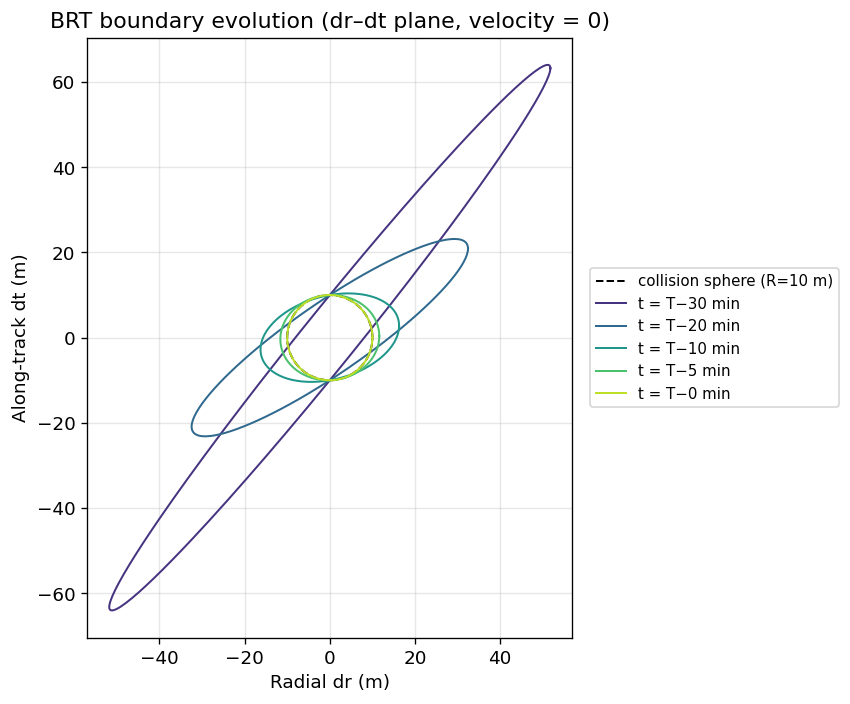

In [3]:
# Sub-orbit deltas (T_geom - t), in minutes, so the shape stays readable.
minute = 60.0
deltas = [0.0, 5*minute, 10*minute, 20*minute, 30*minute]   # T_geom - t
times = sorted({max(T_geom - d, 0.0) for d in deltas})
colors = cm.viridis(np.linspace(0.15, 0.9, len(times)))

fig, ax = plt.subplots(figsize=(7, 6))

# Collision sphere (target set) outline
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(R_hbr*np.cos(theta), R_hbr*np.sin(theta), 'k--', lw=1.2,
        label=f'collision sphere (R={R_hbr:.0f} m)')

for c, t in zip(colors, times):
    pts = brt_boundary_points(t, T_geom, n, hard_body_r=R_hbr, n_samples=200,
                              velocity=np.zeros(3))
    closed = np.vstack([pts[:, :2], pts[0, :2]])
    ax.plot(closed[:, 0], closed[:, 1], color=c, lw=1.2,
            label=f't = T−{(T_geom - t)/60:.0f} min')

ax.set_xlabel('Radial dr (m)')
ax.set_ylabel('Along-track dt (m)')
ax.set_title('BRT boundary evolution (dr–dt plane, velocity = 0)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.savefig('../figures/02_brt_boundary_evolution.png', dpi=120, bbox_inches='tight')
plt.show()

## Figure 2 — BRT value field at the scenario's TRUE encounter velocity (dn–dr)

The genuine HJ-reachability membership figure, but plotted at the **scenario's
actual state**, not an arbitrary velocity slice. Two facts about this crossing
set the plane and the framing:

- The encounter is almost entirely **cross-track**: at TCA the true relative
  velocity is `[0, 0, 7000]` m/s (pure `dn`), the radial miss is `dr = 1000` m,
  and `dt = 0`. So we plot positions in the **dn–dr plane**, holding the other
  components at their true TCA values, and color the continuous BRT value
  `V(x)` (RdBu_r, centered 0): **blue = inside the BRT** (V < 0, the position —
  carried at the real 7 km/s velocity — reaches the 10 m sphere within the
  window), **red = safe**, black = the `V = 0` boundary.
- `dt` is **not** globally small — it sweeps 0 → 565 km over the full window; it
  is ≈ 0 *only at TCA*. That is exactly why a TCA-zoom lives in the dn–dr plane.
  (We therefore do **not** plot the full-window path here — only the ±2 s window
  around TCA, where the dn–dr plane is faithful.)

**Two panels:**
- **Panel A — radial context (true scale):** the nominal path (green) sits at
  `dr = 1000` m; the BRT tube is the tiny capsule at `dr = 0`. The large red gap
  between them is the physical point: *the nominal trajectory is ~1 km of pure
  safe margin away from the BRT.* For a real conjunction the risk is not on the
  nominal path at all — it lives in the **covariance tail** (the magenta sample),
  which is what Pc(t) integrates in Step 5.
- **Panel B — zoom on the tube:** the BRT is a clean capsule around the sphere.
  The magenta **colliding tail sample** (a deep covariance-tail draw, like
  Fig 3B — illustrative, not a fair MC draw) passes through and **enters** it.
  The capsule opens toward −dn: an upstream state (negative dn) carried at
  +7 km/s still reaches the sphere later in the window, so it is inside the BRT.

**What correct looks like:**
- V smooth and negative inside, rising through 0 at the boundary; the boundary
  **encloses** the collision sphere; `Vmin = −R_hbr` at the tube center.
- The nominal point is deep red (`V ≫ 0`, safe); the tail sample enters the tube.

**Failure modes:** colors swapped (sphere in red) → sign inverted; tube does not
enclose the sphere, or `Vmin ≠ −R_hbr` → resolution/sign bug; nominal shows as
unsafe → wrong fixed state.

*Resolution:* `method='refine'` here — at 7 km/s the in-sphere dwell is ~ms, so a
coarse uniform τ grid would step over it; this is precisely the case the
bracket+refine resolution exists for. Grids are ~120/axis (≈1 m/pixel) so each
panel renders in a few seconds.

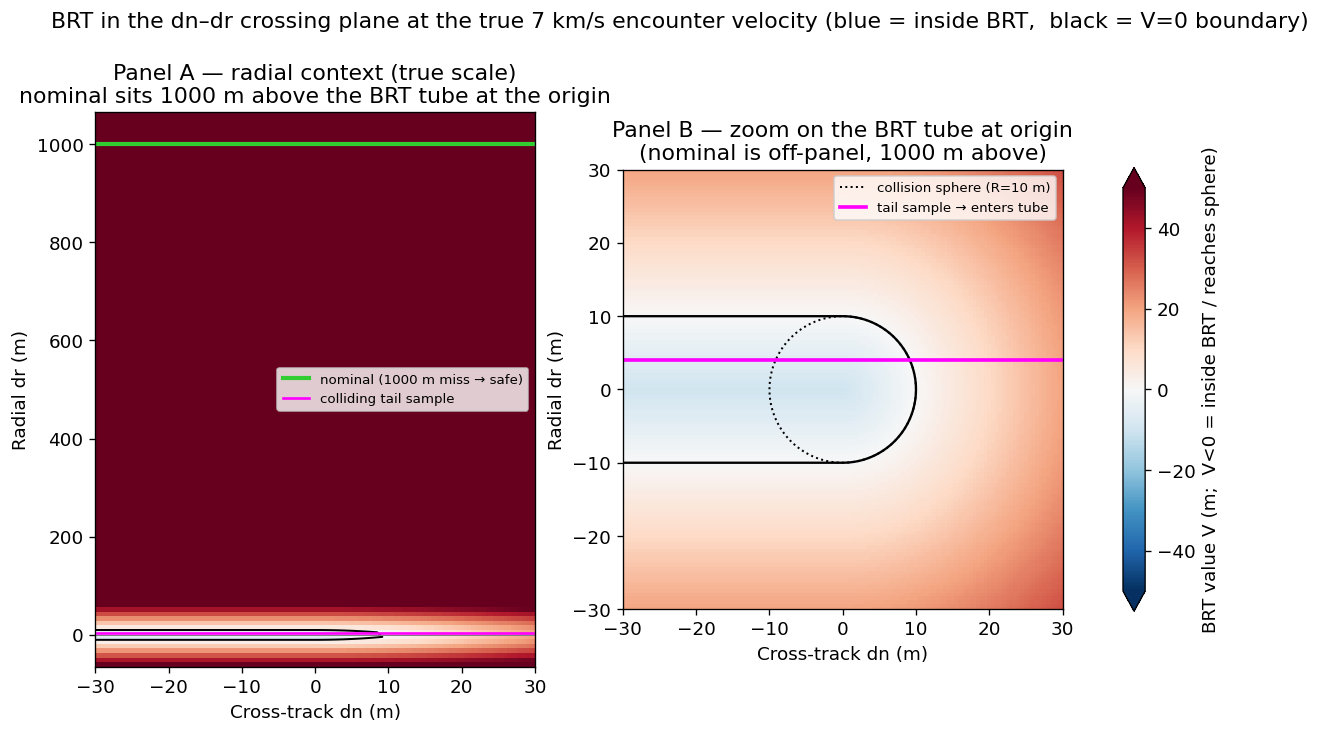

nominal point V (dr=1000, dn=0, true vel) = 990.0 m  -> >> 0, SAFE (nominal never enters the tube)
tail-sample min separation near TCA = 4.37 m  (< R_hbr=10: enters the tube)
nominal       min separation near TCA = 1000.0 m  (= miss distance)
Panel B inside-BRT cells = 2982 | Vmin = -10.0 m (= -R_hbr at tube center)


In [4]:
# =============================================================================
# Figure 2 -- BRT value field in the dn-dr plane, at the SCENARIO'S TRUE state,
# with TWO panels: (A) wide context at true scale, (B) origin zoom on the tube.
# =============================================================================
# Why dn-dr (not dr-dt): this crossing is almost entirely cross-track. At TCA
# the TRUE relative velocity is [0, 0, 7000] m/s (pure dn), the radial miss is
# dr = 1000 m, and dt = 0. (dt is NOT globally small -- it sweeps 0..565 km over
# the full window -- it is ~0 ONLY at TCA, which is exactly why the TCA-zoom
# lives in the dn-dr plane.) We hold the non-plotted components at their true
# TCA values and ask the genuine BRT question: "carried at the real 7 km/s
# encounter velocity, does this position reach the 10 m sphere within the
# remaining window?"  V <= 0  <=>  inside the BRT.
period = 2 * np.pi / n
T_geom = period / 2   # (still used by Fig 1)

# Fixed (non-plotted) components = scenario's actual values AT TCA.
x_tca = hcw_state_transition(n, T) @ scenario.x0     # [1000, 0, 0, 0, 0, 7000]
vel_true = x_tca[3:].copy()
dt_fixed = x_tca[1]                                   # = 0 at TCA

# Evaluate the BRT 2 s before TCA so there is a real remaining window for a
# trajectory to flow through the tube (+/- 14 km of dn travel at 7 km/s).
t_brt = T - 2.0
DN_VIEW = 30.0   # dn half-width shown in BOTH panels (the tube is ~10 m wide)

def brt_field_dndr(dn_axis, dr_axis):
    """BRT value V on a dn-dr grid, other dims fixed to the true TCA state.

    method='refine': at 7 km/s the in-sphere dwell is ~ms, so a coarse uniform
    tau grid would step OVER the passage -- this is exactly the case that needs
    the bracket+refine resolution. Grids are kept modest (~120/axis, ~1 m/pix)
    so each panel renders in a few seconds (value() rebuilds one expm per tau
    sample per call; a finer grid is a Step-5 perf item, not needed here).
    """
    DN, DR = np.meshgrid(dn_axis, dr_axis)
    X = np.zeros((DN.size, 6))
    X[:, 0] = DR.ravel()        # dr
    X[:, 1] = dt_fixed          # dt fixed at TCA value (0)
    X[:, 2] = DN.ravel()        # dn
    X[:, 3:] = vel_true         # TRUE relative velocity
    V = value(X, t=t_brt, T=T, n=n, hard_body_r=R_hbr, method='refine')
    return DN, DR, V.reshape(DN.shape)

# --- overlay trajectories near TCA (dn on x, dr on y) ---
# Restrict to the dn view window so the lines don't autoscale the axes out to
# the +/- 14 km the tail covers in the 2 s window.
tt = np.linspace(T - 2.0, T + 2.0, 8000)
nom = propagate_hcw(scenario.x0, (0.0, tt[-1]), tt, n)          # nominal: 1000 m miss
s_tca = x_tca.copy(); s_tca[0] = 0.4 * R_hbr                     # tail: pulled into sphere
x0_tail = hcw_state_transition(n, -T) @ s_tca
tail = propagate_hcw(x0_tail, (0.0, tt[-1]), tt, n)
def _clip_dn(traj):
    m = np.abs(traj[:, 2]) <= DN_VIEW
    return traj[m]
nom_v, tail_v = _clip_dn(nom), _clip_dn(tail)

import matplotlib.colors as mcolors
norm = mcolors.TwoSlopeNorm(vmin=-50.0, vcenter=0.0, vmax=50.0)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 6))

# ---- Panel A: WIDE context in dr (nominal at 1000 m above the tiny tube) ----
gA = 121
dnA = np.linspace(-DN_VIEW, DN_VIEW, gA)
drA = np.linspace(-60.0, x_tca[0] + 60.0, gA)        # 0-ish up past the 1000 m miss
DNa, DRa, Va = brt_field_dndr(dnA, drA)
pcmA = axA.pcolormesh(DNa, DRa, Va, cmap='RdBu_r', norm=norm, shading='auto')
axA.contour(DNa, DRa, Va, levels=[0], colors='k', linewidths=1.2)
axA.plot(nom_v[:, 2], nom_v[:, 0], color='limegreen', lw=2.5,
         label='nominal (1000 m miss → safe)')
axA.plot(tail_v[:, 2], tail_v[:, 0], color='magenta', lw=1.6,
         label='colliding tail sample')
axA.axhline(0.0, color='gray', lw=0.6)
axA.set_xlim(-DN_VIEW, DN_VIEW)
axA.set_xlabel('Cross-track dn (m)'); axA.set_ylabel('Radial dr (m)')
axA.set_title('Panel A — radial context (true scale)\n'
              'nominal sits 1000 m above the BRT tube at the origin')
axA.legend(fontsize=8, loc='center right')

# ---- Panel B: ZOOM on the BRT tube at the origin (tail sample entering) ----
gB = 121
DNb, DRb, Vb = brt_field_dndr(np.linspace(-DN_VIEW, DN_VIEW, gB),
                              np.linspace(-DN_VIEW, DN_VIEW, gB))
pcmB = axB.pcolormesh(DNb, DRb, Vb, cmap='RdBu_r', norm=norm, shading='auto')
axB.contour(DNb, DRb, Vb, levels=[0], colors='k', linewidths=1.4)   # BRT boundary
axB.plot(R_hbr*np.cos(theta), R_hbr*np.sin(theta), 'k:', lw=1.2,
         label=f'collision sphere (R={R_hbr:.0f} m)')
axB.plot(tail_v[:, 2], tail_v[:, 0], color='magenta', lw=2.2,
         label='tail sample → enters tube')
axB.set_xlabel('Cross-track dn (m)'); axB.set_ylabel('Radial dr (m)')
axB.set_xlim(-DN_VIEW, DN_VIEW); axB.set_ylim(-DN_VIEW, DN_VIEW); axB.set_aspect('equal')
axB.set_title('Panel B — zoom on the BRT tube at origin\n(nominal is off-panel, 1000 m above)')
axB.legend(fontsize=8, loc='upper right')

fig.colorbar(pcmB, ax=[axA, axB], shrink=0.8, extend='both',
             label='BRT value V (m;  V<0 = inside BRT / reaches sphere)')
fig.suptitle('BRT in the dn–dr crossing plane at the true 7 km/s encounter velocity '
             '(blue = inside BRT,  black = V=0 boundary)', y=1.02)
plt.savefig('../figures/02_brt_membership_map.png', dpi=120, bbox_inches='tight')
plt.show()

# --- sanity diagnostics ---
print('nominal point V (dr=1000, dn=0, true vel) =',
      round(float(value(x_tca, t=t_brt, T=T, n=n, hard_body_r=R_hbr)), 1),
      'm  -> >> 0, SAFE (nominal never enters the tube)')
print('tail-sample min separation near TCA =',
      round(float(np.linalg.norm(tail[:, :3], axis=1).min()), 2),
      f'm  (< R_hbr={R_hbr:.0f}: enters the tube)')
print('nominal       min separation near TCA =',
      round(float(np.linalg.norm(nom[:, :3], axis=1).min()), 1),
      'm  (= miss distance)')
print('Panel B inside-BRT cells =', int((Vb < 0).sum()),
      '| Vmin =', round(float(Vb.min()), 2), 'm (= -R_hbr at tube center)')

## Figure 3 — value along a trajectory (bridge to trusted code)

Two curves per trajectory:
- **Curve A** — `V(x(t), t)` = the **tube** value = "will I be in the sphere at
  **any** τ ≥ t before T?" (running minimum of future signed distance).
- **Curve B** — `l(x(t)) = separation − R_hbr` = "am I in the sphere *now*?"

They are **not** expected to coincide except near **t = T**, where Φ→I so V→l.

**Tube signature (the key meaning shift from the old single-time set):** for a
trajectory that *will* pass through the sphere, Curve A is **flat and negative
across the whole pre-TCA window** — the tube already knows the collision is
coming, from the very start, so V stays ≈ (min separation − R_hbr) until the
window shortens past TCA. The old single-time set would instead dip negative
only in the instant around TCA. A flat-negative V before TCA that then rises
toward l after TCA is exactly the running-minimum / monotonicity behaviour.

**What correct looks like:**
- Curve A is **non-decreasing in t** (monotonicity): remaining risk only shrinks
  as the window shortens.
- Near t = T the two curves **converge** (V(x,T)=l(x) exactly).
- Curve A goes negative **no later than** Curve B (future collision known before
  present collision). If A goes negative *later*, time-direction is suspect.

**Failure mode:** curves identical everywhere → value() isn't propagating; or
Curve A wiggles/decreases in t → the min-over-window (tube) is broken.

### Figure 3A — nominal trajectory, artificially close (5 m miss)

⚠️ This is an **artificially close** trajectory (`miss_distance = 5 m`) used
only to exercise the V<0 branch on the *nominal* path. It is **not a realistic
conjunction** — a real 1 km miss never enters a 10 m sphere. Figure 3B uses the
realistic case.


3A nominal miss distance = 5.00 m (R_hbr = 10 m)


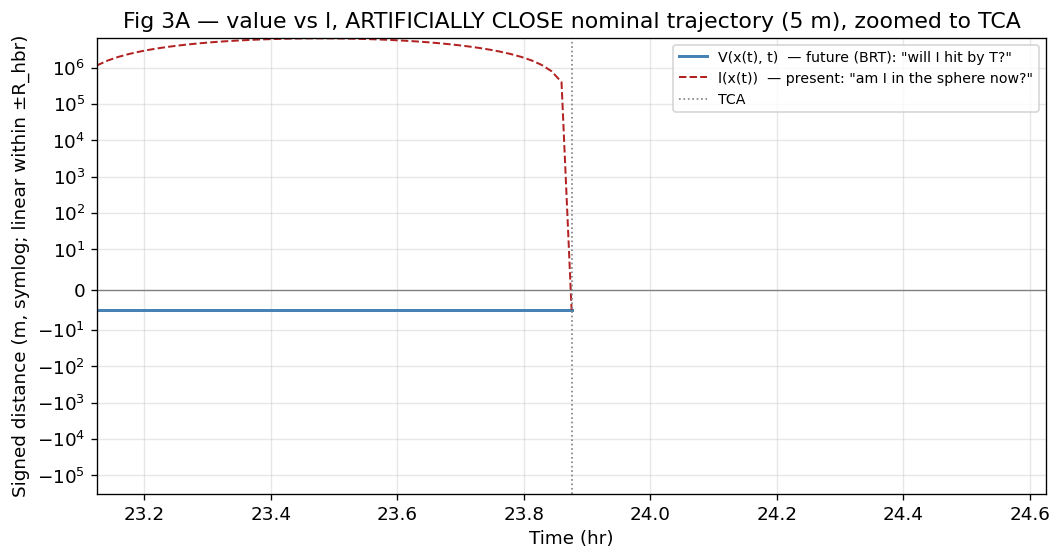

In [5]:
sc_close = make_crossing_conjunction(altitude_km=550.0, miss_distance=0.005,
                                     relative_velocity_mps=7000.0)
T_c = sc_close.t_horizon
t_eval, states = sc_close.propagate(n_steps=1500)
V_traj = value_along_trajectory(states, t_eval, T_c, sc_close.n, sc_close.hard_body_r)
l_traj = signed_distance(states, hard_body_r=sc_close.hard_body_r)
t_tca, d_tca = time_of_closest_approach(states, t_eval)
print(f"3A nominal miss distance = {d_tca:.2f} m (R_hbr = {sc_close.hard_body_r:.0f} m)")

def plot_value_vs_l(t_eval, V_traj, l_traj, t_tca, title, savepath,
                    zoom_hr=0.75):
    """Plot V vs l on a symlog y-axis.

    Why symlog: along this crossing trajectory l(x(t)) (present separation) ranges
    over hundreds of km away from TCA, while V(x(t),t) (future BRT value) stays
    ~constant and NEGATIVE (the future collision outcome is fixed). On a linear
    axis l's huge excursion crushes V flat against zero. symlog shows both the
    -m-scale V floor and the 100s-of-km l arc, and their meeting at TCA.
    """
    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.plot(t_eval/3600, V_traj, 'steelblue', lw=1.8,
            label='V(x(t), t)  — future (BRT): "will I hit by T?"')
    ax.plot(t_eval/3600, l_traj, 'firebrick', lw=1.2, ls='--',
            label='l(x(t))  — present: "am I in the sphere now?"')
    ax.axhline(0, color='gray', lw=0.8)
    ax.axvline(t_tca/3600, color='gray', ls=':', lw=1.0, label='TCA')
    ax.set_yscale('symlog', linthresh=10.0)   # linear within +/-10 m (= R_hbr), log beyond
    lo, hi = (t_tca - zoom_hr*3600)/3600, (t_tca + zoom_hr*3600)/3600
    ax.set_xlim(lo, hi)
    ax.set_xlabel('Time (hr)')
    ax.set_ylabel('Signed distance (m, symlog; linear within ±R_hbr)')
    ax.set_title(title); ax.legend(fontsize=8.5, loc='upper right')
    ax.grid(True, alpha=0.3, which='both')
    plt.tight_layout(); plt.savefig(savepath, dpi=120); plt.show()

plot_value_vs_l(t_eval, V_traj, l_traj, t_tca,
                'Fig 3A — value vs l, ARTIFICIALLY CLOSE nominal trajectory (5 m), zoomed to TCA',
                '../figures/02_value_along_trajectory.png')

### Figure 3.0 — why we must define the covariance AT TCA, not at t=0

The scenario's CDM covariance is specified at the start of the window. If we
propagate it forward to TCA, the small along-track *velocity* uncertainty
(σ_ṫ ≈ 0.1 m/s) integrates over ~24 hr and blows the along-track *position*
σ up to tens of km — the cloud smears into a giant along-track streak and
essentially nothing lands in the 10 m sphere (≈ 0 resolvable collisions).

So start-of-window covariance is the **wrong object** to sample for Pc. The
standard conjunction convention defines the covariance **at TCA**. This figure
shows the blow-up directly; Figure 3B then samples at TCA.

**What correct looks like:** the along-track (dt) σ grows by orders of magnitude
across the window while radial/cross-track stay roughly flat. That growth IS the
reason for sampling at TCA.


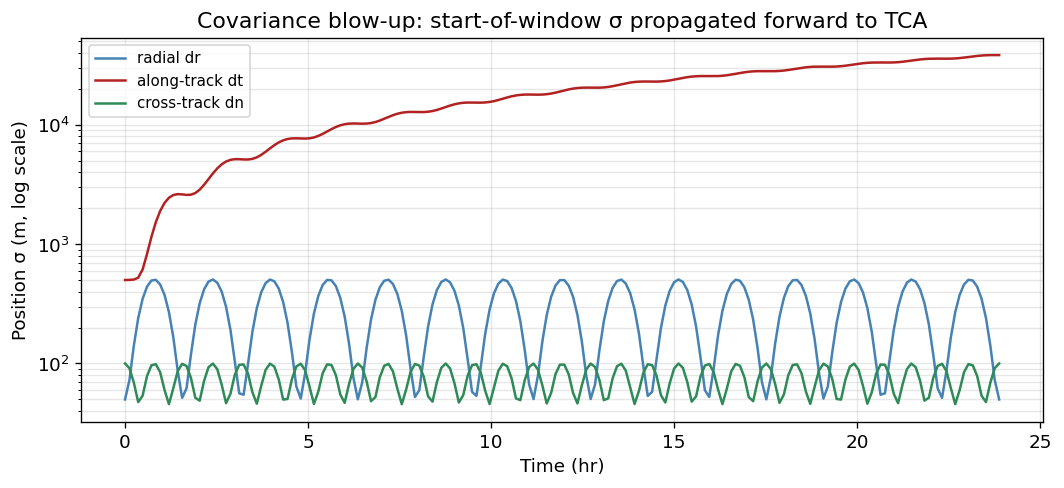

along-track σ: 500 m at t=0  ->  38270 m at TCA


In [6]:
tt = np.linspace(0.0, T, 200)
sig = np.zeros((tt.size, 3))
for i, t in enumerate(tt):
    phi = hcw_state_transition(n, t)
    cov_t = phi @ scenario.covariance @ phi.T
    sig[i] = np.sqrt(np.diag(cov_t)[:3])

fig, ax = plt.subplots(figsize=(9, 4.2))
for k, (lab, c) in enumerate([('radial dr', 'steelblue'),
                              ('along-track dt', 'firebrick'),
                              ('cross-track dn', 'seagreen')]):
    ax.semilogy(tt/3600, sig[:, k], color=c, lw=1.5, label=lab)
ax.set_xlabel('Time (hr)'); ax.set_ylabel('Position σ (m, log scale)')
ax.set_title('Covariance blow-up: start-of-window σ propagated forward to TCA')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('../figures/02_covariance_blowup.png', dpi=120)
plt.show()
print(f"along-track σ: {sig[0,1]:.0f} m at t=0  ->  {sig[-1,1]:.0f} m at TCA")

### Figure 3B — an illustrative colliding tail event (R_hbr = 10 m, realistic)

We keep the **realistic** 10 m hard-body radius and the conjunction convention
of defining the CDM covariance **at TCA** (motivated by Fig 3.0). But note the
physics: with R_hbr = 10 m and radial σ ≈ 50 m, a real conjunction has
**Pc ≈ 1e-4** — naive Monte Carlo would need ~10⁶–10⁸ samples to see a single
collision, because the 10 m sphere is a tiny target and inflating σ only spreads
the same mass thinner over it (density at the sphere falls ~1/σ²).

So Fig 3B does **not** estimate Pc by brute-force sampling. It draws **one
collision-conditioned tail sample** — a state deliberately taken from the tail
of `N(x_TCA, Σ)` that *does* pass through the sphere — purely to exercise the
`V < 0` branch on a physically meaningful (if rare) event. This is an
**illustrative sample, not a fair MC draw**.

**Step 5 plan:** the correct estimator for a Pc ≈ 1e-4 rare event is
**BRT-guided importance sampling** — sample a proposal centered on the unsafe set
`{V < 0}`, then reweight by the Gaussian likelihood ratio. That is a Step-5
deliverable, not this diagnostic.


illustrative tail sample: radial shift = 19.9 sigma_r (this is why Pc is ~1e-4 and needs importance sampling in Step 5)


tail-sample min separation = 4.00 m (< R_hbr = 10 m: True)


chosen sample min separation = 4.00 m at t = 23.876 hr


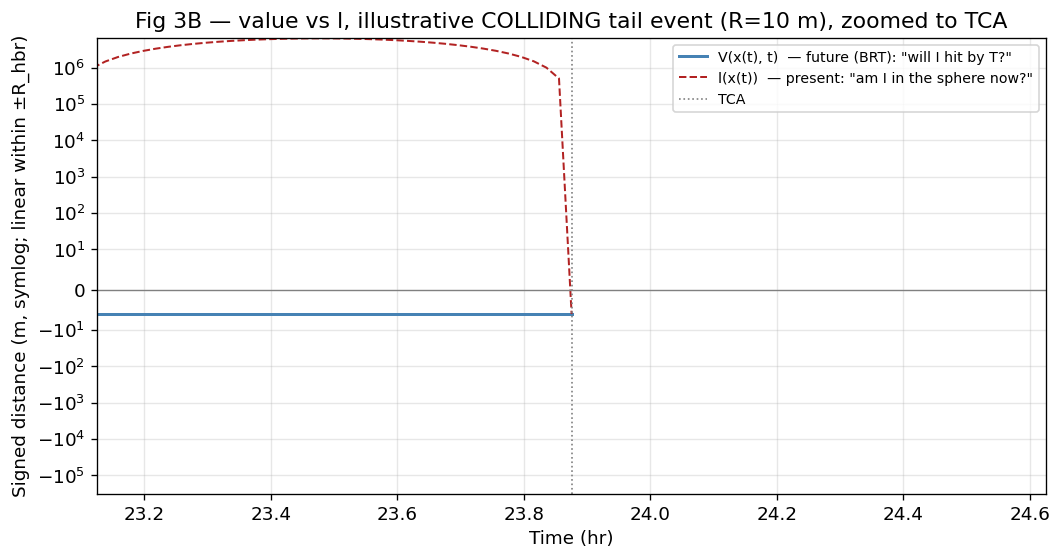

In [7]:
# CDM covariance defined AT TCA (= T); nominal state at TCA.
x_tca = hcw_state_transition(n, T) @ scenario.x0     # ~[1000, 0, 0, ...] m
phi_back = hcw_state_transition(n, -T)               # TCA -> t=0
t_eval, _ = scenario.propagate(n_steps=1200)

# Construct ONE collision-conditioned tail sample: place the position inside the
# sphere at TCA (a deep tail draw of the radial component), keep the nominal
# velocity, then back-propagate to t=0 and integrate forward. Guaranteed to
# collide -- this is an illustrative tail event, NOT a fair Monte Carlo draw.
s_tca = x_tca.copy()
s_tca[0] = 0.4 * R_hbr        # radial position pulled into the sphere (~25 sigma_r tail)
s_tca[1] = 0.0
s_tca[2] = 0.0
mahalanobis = abs(x_tca[0] - s_tca[0]) / np.sqrt(scenario.covariance[0, 0])
print(f"illustrative tail sample: radial shift = {mahalanobis:.1f} sigma_r "
      f"(this is why Pc is ~1e-4 and needs importance sampling in Step 5)")

x0 = phi_back @ s_tca
st = propagate_hcw(x0, (0.0, T), t_eval, n)
d_tca_check = separation_distance(st).min()
print(f"tail-sample min separation = {d_tca_check:.2f} m (< R_hbr = {R_hbr:.0f} m: "
      f"{d_tca_check < R_hbr})")
V_traj = value_along_trajectory(st, t_eval, T, n, R_hbr)
l_traj = signed_distance(st, hard_body_r=R_hbr)
t_tca_s, d_tca_s = time_of_closest_approach(st, t_eval)
print(f"chosen sample min separation = {d_tca_s:.2f} m at t = {t_tca_s/3600:.3f} hr")

plot_value_vs_l(t_eval, V_traj, l_traj, t_tca_s,
                'Fig 3B — value vs l, illustrative COLLIDING tail event '
                '(R=10 m), zoomed to TCA',
                '../figures/02_value_along_trajectory_sample.png')

## Next: Step 5 — Pc(t)

Figure 3B is the seed of the headline result: sweep `t` over the window and at
each `t` compute the fraction of covariance samples with `V(x, t) < 0` → the
time-evolving `Pc(t)` curve, plus the latest-safe-maneuver-time `t*`.
